In [53]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd()

assert (DATA_DIR / 'application_train.csv').is_file(), (
    'Start Jupyter from the project folder containing the CSV files.'
)

print('Data folder:', DATA_DIR)

Data folder: C:\Users\q8x7u\Documents\cv\CV\projects\home credit default risk


In [3]:
applications = pd.read_csv(DATA_DIR / 'application_train.csv')

print('Rows and columns:', applications.shape)
applications.head()

Rows and columns: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
assert applications['SK_ID_CURR'].notna().all()
assert applications['SK_ID_CURR'].is_unique
assert applications['TARGET'].notna().all()
assert set(applications['TARGET'].unique()) == {0, 1}

print('Application checks passed')
print(applications['TARGET'].value_counts().sort_index())
print(f"Payment difficulty rate: {applications['TARGET'].mean():.2%}")

Application checks passed
TARGET
0    282686
1     24825
Name: count, dtype: int64
Payment difficulty rate: 8.07%


In [5]:
bureau_columns = [
    'SK_ID_CURR',
    'SK_ID_BUREAU',
    'CREDIT_ACTIVE',
    'DAYS_CREDIT',
    'CREDIT_DAY_OVERDUE',
]

bureau = pd.read_csv(
    DATA_DIR / 'bureau.csv',
    usecols=bureau_columns,
)

assert bureau['SK_ID_CURR'].notna().all()
assert bureau['SK_ID_BUREAU'].notna().all()
assert bureau['SK_ID_BUREAU'].is_unique
assert bureau['DAYS_CREDIT'].notna().all()
assert bureau['DAYS_CREDIT'].le(0).all()

print('Bureau shape:', bureau.shape)
bureau.head()

Bureau shape: (1716428, 5)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,DAYS_CREDIT,CREDIT_DAY_OVERDUE
0,215354,5714462,Closed,-497,0
1,215354,5714463,Active,-208,0
2,215354,5714464,Active,-203,0
3,215354,5714465,Active,-203,0
4,215354,5714466,Active,-629,0


In [6]:
bureau['IS_ACTIVE'] = (
    bureau['CREDIT_ACTIVE'].eq('Active').astype('int8')
)

bureau_features = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'size'),
    BUREAU_ACTIVE_COUNT=('IS_ACTIVE', 'sum'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_DAYS_SINCE_MOST_RECENT=('DAYS_CREDIT', 'max'),
)

bureau_features['BUREAU_DAYS_SINCE_MOST_RECENT'] = (
    bureau_features['BUREAU_DAYS_SINCE_MOST_RECENT'].abs()
)

bureau_features['BUREAU_ACTIVE_SHARE'] = (
    bureau_features['BUREAU_ACTIVE_COUNT']
    / bureau_features['BUREAU_LOAN_COUNT']
)

bureau_features = bureau_features.reset_index()

assert bureau_features['SK_ID_CURR'].is_unique
assert bureau_features['BUREAU_ACTIVE_SHARE'].between(0, 1).all()

print('Feature table shape:', bureau_features.shape)
bureau_features.head()

Feature table shape: (305811, 6)


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_MAX_OVERDUE_DAYS,BUREAU_DAYS_SINCE_MOST_RECENT,BUREAU_ACTIVE_SHARE
0,100001,7,3,0,49,0.428571
1,100002,8,2,0,103,0.250000
2,100003,4,1,0,606,0.250000
3,100004,2,0,0,408,0.000000
4,100005,3,2,0,62,0.666667


In [7]:
example_id = 100002

display(
    bureau.loc[
        bureau['SK_ID_CURR'].eq(example_id),
        bureau_columns,
    ].sort_values('DAYS_CREDIT')
)

display(
    bureau_features.loc[
        bureau_features['SK_ID_CURR'].eq(example_id)
    ]
)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,DAYS_CREDIT,CREDIT_DAY_OVERDUE
675686,100002,6158906,Closed,-1437,0
675684,100002,6158904,Closed,-1125,0
675687,100002,6158907,Closed,-1121,0
1486113,100002,6113835,Closed,-1043,0
1337779,100002,6158903,Active,-1042,0
675688,100002,6158908,Closed,-645,0
675685,100002,6158905,Closed,-476,0
675689,100002,6158909,Active,-103,0


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_MAX_OVERDUE_DAYS,BUREAU_DAYS_SINCE_MOST_RECENT,BUREAU_ACTIVE_SHARE
1,100002,8,2,0,103,0.25


In [8]:
model_data = applications.merge(
    bureau_features,
    on='SK_ID_CURR',
    how='left',
    validate='one_to_one',
)

model_data['HAS_BUREAU_RECORD'] = (
    model_data['BUREAU_LOAN_COUNT'].notna().astype('int8')
)

# Zero means no matching accounts in the supplied bureau table.
count_columns = [
    'BUREAU_LOAN_COUNT',
    'BUREAU_ACTIVE_COUNT',
]

model_data[count_columns] = (
    model_data[count_columns].fillna(0).astype('int32')
)

assert len(model_data) == len(applications)
assert model_data['SK_ID_CURR'].is_unique
assert model_data['TARGET'].equals(applications['TARGET'])

print('Model table shape:', model_data.shape)
print('With bureau records:', model_data['HAS_BUREAU_RECORD'].sum())
print('Without bureau records:', model_data['HAS_BUREAU_RECORD'].eq(0).sum())

Model table shape: (307511, 128)
With bureau records: 263491
Without bureau records: 44020


C:\Users\q8x7u\AppData\Local\Temp\ipykernel_308\1910993063.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_data['HAS_BUREAU_RECORD'] = (


In [9]:
model_data = applications.merge(
    bureau_features,
    on='SK_ID_CURR',
    how='left',
    validate='one_to_one',
)

# Consolidate the DataFrame's memory blocks.
model_data = model_data.copy()

model_data['HAS_BUREAU_RECORD'] = (
    model_data['BUREAU_LOAN_COUNT'].notna().astype('int8')
)

In [10]:
payment_columns = [
    'SK_ID_CURR',
    'DAYS_INSTALMENT',
    'DAYS_ENTRY_PAYMENT',
    'AMT_PAYMENT',
]

payment_parts = []
total_rows = 0
included_rows = 0

for chunk in pd.read_csv(
    DATA_DIR / 'installments_payments.csv',
    usecols=payment_columns,
    chunksize=250_000,
):
    total_rows += len(chunk)

    eligible = (
        chunk['SK_ID_CURR'].notna()
        & chunk['DAYS_INSTALMENT'].lt(0)
        & chunk['DAYS_ENTRY_PAYMENT'].lt(0)
        & chunk['AMT_PAYMENT'].gt(0)
    )

    history = chunk.loc[eligible].copy()
    included_rows += len(history)

    history['DELAY_DAYS'] = (
        history['DAYS_ENTRY_PAYMENT']
        - history['DAYS_INSTALMENT']
    ).clip(lower=0)

    history['IS_LATE'] = (
        history['DELAY_DAYS'].gt(0).astype('int8')
    )

    summary = history.groupby('SK_ID_CURR').agg(
        PAYMENT_RECORD_COUNT=('DELAY_DAYS', 'size'),
        LATE_RECORD_COUNT=('IS_LATE', 'sum'),
        DELAY_SUM=('DELAY_DAYS', 'sum'),
        PAYMENT_MAX_DELAY_DAYS=('DELAY_DAYS', 'max'),
    )

    payment_parts.append(summary)

print('Source rows:', total_rows)
print('Included rows:', included_rows)
print('Excluded rows:', total_rows - included_rows)

Source rows: 13605401
Included rows: 13601056
Excluded rows: 4345


In [11]:
payment_totals = (
    pd.concat(payment_parts)
    .groupby(level=0)
    .agg({
        'PAYMENT_RECORD_COUNT': 'sum',
        'LATE_RECORD_COUNT': 'sum',
        'DELAY_SUM': 'sum',
        'PAYMENT_MAX_DELAY_DAYS': 'max',
    })
)

payment_totals['PAYMENT_LATE_RECORD_SHARE'] = (
    payment_totals['LATE_RECORD_COUNT']
    / payment_totals['PAYMENT_RECORD_COUNT']
)

payment_totals['PAYMENT_MEAN_DELAY_DAYS'] = (
    payment_totals['DELAY_SUM']
    / payment_totals['PAYMENT_RECORD_COUNT']
)

payment_features = (
    payment_totals
    .drop(columns=['LATE_RECORD_COUNT', 'DELAY_SUM'])
    .reset_index()
)

assert payment_features['SK_ID_CURR'].is_unique
assert payment_features['PAYMENT_RECORD_COUNT'].sum() == included_rows
assert payment_features['PAYMENT_LATE_RECORD_SHARE'].between(0, 1).all()
assert (
    payment_features['PAYMENT_MEAN_DELAY_DAYS']
    <= payment_features['PAYMENT_MAX_DELAY_DAYS']
).all()

print('Payment feature shape:', payment_features.shape)
payment_features.head()

Payment feature shape: (339578, 5)


,SK_ID_CURR,PAYMENT_RECORD_COUNT,PAYMENT_MAX_DELAY_DAYS,PAYMENT_LATE_RECORD_SHARE,PAYMENT_MEAN_DELAY_DAYS
0,100001,7,11.0,0.142857,1.571429
1,100002,19,0.0,0.000000,0.000000
2,100003,25,0.0,0.000000,0.000000
3,100004,3,0.0,0.000000,0.000000
4,100005,9,1.0,0.111111,0.111111


In [12]:
payment_feature_columns = (
    payment_features.columns.drop('SK_ID_CURR').tolist()
)

model_data = (
    model_data.drop(
        columns=payment_feature_columns + ['HAS_PAYMENT_HISTORY'],
        errors='ignore',
    )
    .merge(
        payment_features,
        on='SK_ID_CURR',
        how='left',
        validate='one_to_one',
    )
    .copy()
)

model_data['HAS_PAYMENT_HISTORY'] = (
    model_data['PAYMENT_RECORD_COUNT'].notna().astype('int8')
)

model_data['PAYMENT_RECORD_COUNT'] = (
    model_data['PAYMENT_RECORD_COUNT']
    .fillna(0)
    .astype('int32')
)

assert len(model_data) == len(applications)
assert model_data['SK_ID_CURR'].is_unique
assert model_data['TARGET'].equals(applications['TARGET'])

print('Model table shape:', model_data.shape)
print('With eligible payments:', model_data['HAS_PAYMENT_HISTORY'].sum())
print(
    'Without eligible payments:',
    model_data['HAS_PAYMENT_HISTORY'].eq(0).sum(),
)

Model table shape: (307511, 133)
With eligible payments: 291635
Without eligible payments: 15876


In [13]:
from sklearn.model_selection import train_test_split

assert model_data.index.is_unique
assert model_data['SK_ID_CURR'].is_unique

train_idx, remaining_idx = train_test_split(
    model_data.index,
    test_size=0.40,
    stratify=model_data['TARGET'],
    random_state=42,
)

valid_idx, test_idx = train_test_split(
    remaining_idx,
    test_size=0.50,
    stratify=model_data.loc[remaining_idx, 'TARGET'],
    random_state=42,
)

split_summary = pd.DataFrame([
    {
        'Dataset': name,
        'Applications': len(idx),
        'Positive cases': int(model_data.loc[idx, 'TARGET'].sum()),
        'Target rate': model_data.loc[idx, 'TARGET'].mean(),
    }
    for name, idx in [
        ('Training', train_idx),
        ('Validation', valid_idx),
        ('Test', test_idx),
    ]
])

display(
    split_summary.style.format({
        'Applications': '{:,.0f}',
        'Positive cases': '{:,.0f}',
        'Target rate': '{:.4%}',
    })
)

,Dataset,Applications,Positive cases,Target rate
0,Training,"184,506","14,895",8.0729%
1,Validation,"61,502","4,965",8.0729%
2,Test,"61,503","4,965",8.0728%


In [14]:
train_ids = set(model_data.loc[train_idx, 'SK_ID_CURR'])
valid_ids = set(model_data.loc[valid_idx, 'SK_ID_CURR'])
test_ids = set(model_data.loc[test_idx, 'SK_ID_CURR'])

assert train_ids.isdisjoint(valid_ids)
assert train_ids.isdisjoint(test_ids)
assert valid_ids.isdisjoint(test_ids)

assert len(train_ids | valid_ids | test_ids) == len(model_data)

print('Passed: no application appears in more than one set')
print('Passed: every application belongs to a set')

Passed: no application appears in more than one set
Passed: every application belongs to a set


In [15]:
feature_columns = model_data.columns.drop(
    ['SK_ID_CURR', 'TARGET']
).tolist()

X_train = model_data.loc[train_idx, feature_columns].copy()
y_train = model_data.loc[train_idx, 'TARGET'].copy()

X_valid = model_data.loc[valid_idx, feature_columns].copy()
y_valid = model_data.loc[valid_idx, 'TARGET'].copy()

X_test = model_data.loc[test_idx, feature_columns].copy()
y_test = model_data.loc[test_idx, 'TARGET'].copy()

assert X_train.columns.equals(X_valid.columns)
assert X_train.columns.equals(X_test.columns)
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
assert X_test.index.equals(y_test.index)

print('Training predictors:', X_train.shape)
print('Validation predictors:', X_valid.shape)
print('Test predictors:', X_test.shape)

Training predictors: (184506, 131)
Validation predictors: (61502, 131)
Test predictors: (61503, 131)


In [16]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

numeric_columns = (
    X_train.select_dtypes(include='number').columns.tolist()
)

categorical_columns = (
    X_train.columns.difference(numeric_columns).tolist()
)

# Standardise the representation of missing categorical values.
# This does not learn anything from the validation data.
for frame in [X_train, X_valid]:
    frame[categorical_columns] = (
        frame[categorical_columns]
        .astype(object)
        .where(frame[categorical_columns].notna(), np.nan)
    )

print('Numeric predictors:', len(numeric_columns))
print('Categorical predictors:', len(categorical_columns))

Numeric predictors: 115
Categorical predictors: 16


In [17]:
numeric_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median', add_indicator=True),
    ),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent'),
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True,
        ),
    ),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_columns),
        ('categorical', categorical_pipeline, categorical_columns),
    ],
    sparse_threshold=1.0,
)

print('Preprocessing configured')

Preprocessing configured


In [18]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        LogisticRegression(
            solver='lbfgs',
            C=1.0,
            max_iter=2000,
        ),
    ),
])

logistic_model.fit(X_train, y_train)

iterations = logistic_model.named_steps['model'].n_iter_[0]

print('Training completed')
print('Iterations:', iterations)

assert iterations < 2000, 'Iteration limit reached: investigate convergence'

Training completed
Iterations: 135


In [19]:
valid_probability = logistic_model.predict_proba(X_valid)[:, 1]

assert len(valid_probability) == len(y_valid)
assert np.isfinite(valid_probability).all()
assert ((valid_probability >= 0) & (valid_probability <= 1)).all()

validation_auc = roc_auc_score(y_valid, valid_probability)
validation_gini = 2 * validation_auc - 1
validation_brier = brier_score_loss(y_valid, valid_probability)

print(f'Validation AUC:   {validation_auc:.4f}')
print(f'Validation Gini:  {validation_gini:.4f}')
print(f'Validation Brier: {validation_brier:.4f}')

Validation AUC:   0.7532
Validation Gini:  0.5063
Validation Brier: 0.0682


In [20]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_valid,
    valid_probability,
    drop_intermediate=False,
)

ks_value = np.max(true_positive_rate - false_positive_rate)

assert 0 <= ks_value <= 1

print(f'Validation KS: {ks_value:.4f}')

Validation KS: 0.3771


In [21]:
calibration_data = pd.DataFrame({
    'predicted_probability': valid_probability,
    'actual_outcome': y_valid.to_numpy(),
})

calibration_data['risk_group'] = pd.qcut(
    calibration_data['predicted_probability'],
    q=10,
    duplicates='drop',
)

calibration_table = (
    calibration_data
    .groupby('risk_group', observed=True)
    .agg(
        applicants=('actual_outcome', 'size'),
        positive_cases=('actual_outcome', 'sum'),
        mean_predicted_probability=('predicted_probability', 'mean'),
        observed_target_rate=('actual_outcome', 'mean'),
    )
)

calibration_table['observed_minus_predicted'] = (
    calibration_table['observed_target_rate']
    - calibration_table['mean_predicted_probability']
)

assert calibration_table['applicants'].sum() == len(y_valid)
assert calibration_table['positive_cases'].sum() == y_valid.sum()

display(
    calibration_table.style.format({
        'applicants': '{:,.0f}',
        'positive_cases': '{:,.0f}',
        'mean_predicted_probability': '{:.2%}',
        'observed_target_rate': '{:.2%}',
        'observed_minus_predicted': '{:+.2%}',
    })
)

,applicants,positive_cases,mean_predicted_probability,observed_target_rate,observed_minus_predicted
risk_group,,,,,
"(-0.00099476, 0.0167]","6,151",80,1.16%,1.30%,+0.14%
"(0.0167, 0.0249]","6,150",122,2.08%,1.98%,-0.09%
"(0.0249, 0.0333]","6,150",193,2.90%,3.14%,+0.24%
"(0.0333, 0.0429]","6,150",209,3.81%,3.40%,-0.41%
"(0.0429, 0.0547]","6,150",298,4.86%,4.85%,-0.02%
"(0.0547, 0.07]","6,150",388,6.19%,6.31%,+0.12%
"(0.07, 0.0903]","6,150",493,7.96%,8.02%,+0.06%
"(0.0903, 0.122]","6,150",642,10.47%,10.44%,-0.03%
"(0.122, 0.18]","6,150",928,14.69%,15.09%,+0.40%


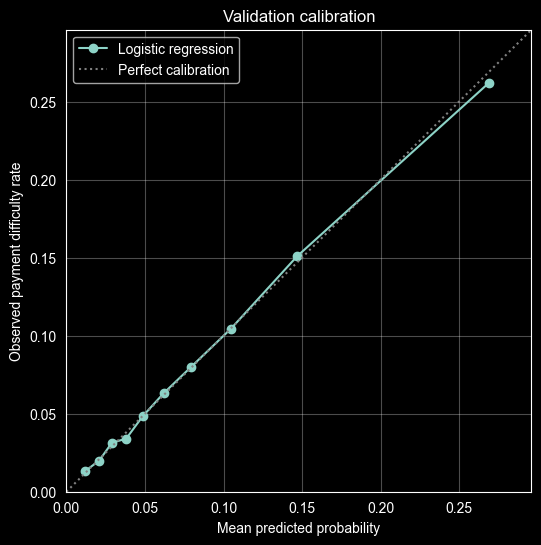

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    calibration_table['mean_predicted_probability'],
    calibration_table['observed_target_rate'],
    marker='o',
    label='Logistic regression',
)

axis_limit = min(
    1.0,
    1.1 * calibration_table[
        ['mean_predicted_probability', 'observed_target_rate']
    ].to_numpy().max(),
)

ax.plot(
    [0, axis_limit],
    [0, axis_limit],
    linestyle=':',
    color='grey',
    label='Perfect calibration',
)

ax.set(
    xlabel='Mean predicted probability',
    ylabel='Observed payment difficulty rate',
    title='Validation calibration',
    xlim=(0, axis_limit),
    ylim=(0, axis_limit),
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [23]:
constant_probability = np.full(
    len(y_valid),
    y_train.mean(),
)

reference_brier = brier_score_loss(
    y_valid,
    constant_probability,
)

validation_brier = brier_score_loss(
    y_valid,
    valid_probability,
)

print(f'Constant baseline Brier:   {reference_brier:.4f}')
print(f'Logistic regression Brier: {validation_brier:.4f}')
print(f'Brier improvement:        {reference_brier - validation_brier:.4f}')

Constant baseline Brier:   0.0742
Logistic regression Brier: 0.0682
Brier improvement:        0.0060


In [24]:
#Logistic regression baseline
# On the validation set, the model achieved AUC of 0.7532,
# Gini of 0.5063, KS of 0.3771 and Brier score of 0.0682.
# The calibration plot showed close agreement between average
# predicted probabilities and observed payment difficulty rates
# across most risk groups. The highest predicted risk group
# showed modest overprediction.
# These results describe a random stratified validation sample.
# They do not establish performance on future applications.
# Calibration was assessed descriptively using grouped predictions,
# without uncertainty intervals.

In [25]:
import importlib.util

if importlib.util.find_spec('lightgbm') is None:
    print('LightGBM needs to be installed')
else:
    import lightgbm as lgb
    print('LightGBM version:', lgb.__version__)

LightGBM version: 4.7.0


In [26]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import lightgbm as lgb

print('LightGBM version:', lgb.__version__)

LightGBM version: 4.7.0


In [28]:
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()

for column in categorical_columns:
    # Learn the available categories from training data only.
    training_categories = (
        X_train_lgb[column].dropna().unique().tolist()
    )

    category_type = pd.CategoricalDtype(
        categories=training_categories
    )

    X_train_lgb[column] = (
        X_train_lgb[column].astype(category_type)
    )

    X_valid_lgb[column] = (
        X_valid_lgb[column].astype(category_type)
    )

assert X_train_lgb.columns.equals(X_valid_lgb.columns)
assert X_train_lgb.index.equals(y_train.index)
assert X_valid_lgb.index.equals(y_valid.index)

print('Training shape:', X_train_lgb.shape)
print('Validation shape:', X_valid_lgb.shape)
print(
    'Categorical columns:',
    len(X_train_lgb.select_dtypes(include='category').columns),
)

Training shape: (184506, 131)
Validation shape: (61502, 131)
Categorical columns: 16


In [29]:
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=100,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=4,
    verbosity=-1,
)

lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_X=X_valid_lgb,
    eval_y=y_valid,
    eval_metric='auc',
    categorical_feature=categorical_columns,
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print('Best iteration:', lgb_model.best_iteration_)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.755156	valid_0's binary_logloss: 0.247853
[200]	valid_0's auc: 0.762736	valid_0's binary_logloss: 0.244724
[300]	valid_0's auc: 0.764909	valid_0's binary_logloss: 0.24391
[400]	valid_0's auc: 0.765874	valid_0's binary_logloss: 0.243625
[500]	valid_0's auc: 0.766207	valid_0's binary_logloss: 0.243524
[600]	valid_0's auc: 0.766212	valid_0's binary_logloss: 0.243509
[700]	valid_0's auc: 0.766557	valid_0's binary_logloss: 0.243431
[800]	valid_0's auc: 0.766573	valid_0's binary_logloss: 0.243418
[900]	valid_0's auc: 0.766443	valid_0's binary_logloss: 0.243482
Early stopping, best iteration is:
[815]	valid_0's auc: 0.766703	valid_0's binary_logloss: 0.24339
Evaluated only: auc
Best iteration: 815


In [30]:
lgb_valid_probability = lgb_model.predict_proba(
    X_valid_lgb,
    num_iteration=lgb_model.best_iteration_,
)[:, 1]

assert np.isfinite(lgb_valid_probability).all()
assert (
    (lgb_valid_probability >= 0)
    & (lgb_valid_probability <= 1)
).all()


def calculate_metrics(y_true, probability):
    auc = roc_auc_score(y_true, probability)

    fpr, tpr, _ = roc_curve(
        y_true,
        probability,
        drop_intermediate=False,
    )

    return {
        'AUC': auc,
        'Gini': 2 * auc - 1,
        'KS': np.max(tpr - fpr),
        'Brier': brier_score_loss(y_true, probability),
    }


validation_comparison = pd.DataFrame({
    'Logistic regression': calculate_metrics(
        y_valid,
        valid_probability,
    ),
    'LightGBM': calculate_metrics(
        y_valid,
        lgb_valid_probability,
    ),
}).T

display(validation_comparison.style.format('{:.4f}'))

,AUC,Gini,KS,Brier
Logistic regression,0.7532,0.5063,0.3771,0.0682
LightGBM,0.7667,0.5334,0.3983,0.0672


In [31]:
lgb_calibration_data = pd.DataFrame({
    'predicted_probability': lgb_valid_probability,
    'actual_outcome': y_valid.to_numpy(),
})

lgb_calibration_data['risk_group'] = pd.qcut(
    lgb_calibration_data['predicted_probability'],
    q=10,
    duplicates='drop',
)

lgb_calibration_table = (
    lgb_calibration_data
    .groupby('risk_group', observed=True)
    .agg(
        applicants=('actual_outcome', 'size'),
        positive_cases=('actual_outcome', 'sum'),
        mean_predicted_probability=('predicted_probability', 'mean'),
        observed_target_rate=('actual_outcome', 'mean'),
    )
)

lgb_calibration_table['observed_minus_predicted'] = (
    lgb_calibration_table['observed_target_rate']
    - lgb_calibration_table['mean_predicted_probability']
)

assert lgb_calibration_table['applicants'].sum() == len(y_valid)
assert lgb_calibration_table['positive_cases'].sum() == y_valid.sum()

display(
    lgb_calibration_table.style.format({
        'applicants': '{:,.0f}',
        'positive_cases': '{:,.0f}',
        'mean_predicted_probability': '{:.2%}',
        'observed_target_rate': '{:.2%}',
        'observed_minus_predicted': '{:+.2%}',
    })
)

,applicants,positive_cases,mean_predicted_probability,observed_target_rate,observed_minus_predicted
risk_group,,,,,
"(0.00066, 0.0164]","6,151",64,1.21%,1.04%,-0.17%
"(0.0164, 0.0232]","6,150",104,1.99%,1.69%,-0.30%
"(0.0232, 0.0305]","6,150",164,2.68%,2.67%,-0.02%
"(0.0305, 0.0391]","6,150",222,3.46%,3.61%,+0.15%
"(0.0391, 0.0497]","6,150",285,4.42%,4.63%,+0.21%
"(0.0497, 0.0641]","6,150",349,5.65%,5.67%,+0.02%
"(0.0641, 0.0848]","6,150",498,7.37%,8.10%,+0.73%
"(0.0848, 0.118]","6,150",648,9.98%,10.54%,+0.55%
"(0.118, 0.185]","6,150",946,14.68%,15.38%,+0.71%


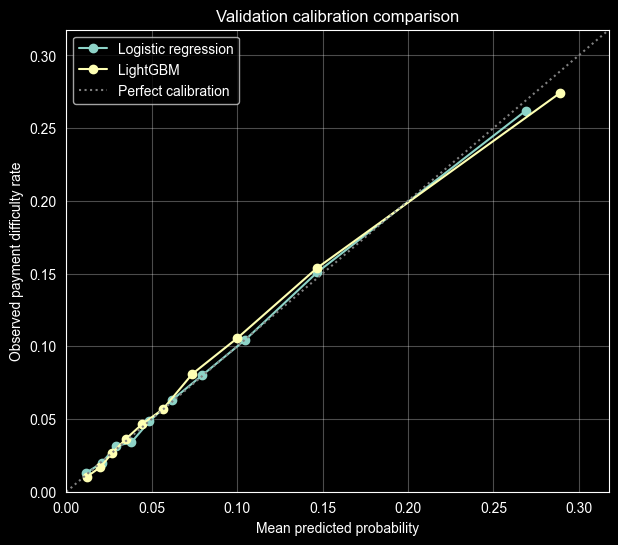

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, table in [
    ('Logistic regression', calibration_table),
    ('LightGBM', lgb_calibration_table),
]:
    ax.plot(
        table['mean_predicted_probability'],
        table['observed_target_rate'],
        marker='o',
        label=name,
    )

plot_columns = [
    'mean_predicted_probability',
    'observed_target_rate',
]

axis_limit = min(
    1.0,
    1.1 * max(
        calibration_table[plot_columns].to_numpy().max(),
        lgb_calibration_table[plot_columns].to_numpy().max(),
    ),
)

ax.plot(
    [0, axis_limit],
    [0, axis_limit],
    linestyle=':',
    color='grey',
    label='Perfect calibration',
)

ax.set(
    xlabel='Mean predicted probability',
    ylabel='Observed payment difficulty rate',
    title='Validation calibration comparison',
    xlim=(0, axis_limit),
    ylim=(0, axis_limit),
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [33]:
# Logistic regression input
X_test_logistic = X_test.copy()

X_test_logistic[categorical_columns] = (
    X_test_logistic[categorical_columns]
    .astype(object)
    .where(
        X_test_logistic[categorical_columns].notna(),
        np.nan,
    )
)

# LightGBM input
X_test_lgb = X_test.copy()

for column in categorical_columns:
    X_test_lgb[column] = X_test_lgb[column].astype(
        X_train_lgb[column].dtype
    )

assert X_test_logistic.columns.equals(X_train.columns)
assert X_test_lgb.columns.equals(X_train_lgb.columns)
assert X_test_logistic.index.equals(y_test.index)
assert X_test_lgb.index.equals(y_test.index)

print('Test preparation passed')
print('Test shape:', X_test_lgb.shape)

Test preparation passed
Test shape: (61503, 131)


In [34]:
logistic_test_probability = logistic_model.predict_proba(
    X_test_logistic
)[:, 1]

lgb_test_probability = lgb_model.predict_proba(
    X_test_lgb,
    num_iteration=lgb_model.best_iteration_,
)[:, 1]

for probability in [
    logistic_test_probability,
    lgb_test_probability,
]:
    assert len(probability) == len(y_test)
    assert np.isfinite(probability).all()
    assert ((probability >= 0) & (probability <= 1)).all()

test_comparison = pd.DataFrame({
    'Logistic regression': calculate_metrics(
        y_test,
        logistic_test_probability,
    ),
    'LightGBM': calculate_metrics(
        y_test,
        lgb_test_probability,
    ),
}).T

display(test_comparison.style.format('{:.4f}'))

,AUC,Gini,KS,Brier
Logistic regression,0.7589,0.5178,0.3890,0.0680
LightGBM,0.7686,0.5373,0.4026,0.0672


In [35]:
evaluation_summary = pd.concat(
    {
        'Validation': validation_comparison,
        'Test': test_comparison,
    },
    names=['Dataset', 'Model'],
)

display(evaluation_summary.style.format('{:.4f}'))

In [36]:
y_test_array = y_test.to_numpy()

logistic_probability = np.asarray(logistic_test_probability)
lightgbm_probability = np.asarray(lgb_test_probability)

assert len(y_test_array) == len(logistic_probability)
assert len(y_test_array) == len(lightgbm_probability)

rng = np.random.default_rng(42)

n_bootstrap = 1000
n_applicants = len(y_test_array)

bootstrap_results = []

for iteration in range(n_bootstrap):
    sampled_rows = rng.integers(
        low=0,
        high=n_applicants,
        size=n_applicants,
    )

    sampled_target = y_test_array[sampled_rows]

    # AUC requires both outcome classes.
    if np.unique(sampled_target).size < 2:
        continue

    logistic_gini = (
        2 * roc_auc_score(
            sampled_target,
            logistic_probability[sampled_rows],
        ) - 1
    )

    lightgbm_gini = (
        2 * roc_auc_score(
            sampled_target,
            lightgbm_probability[sampled_rows],
        ) - 1
    )

    bootstrap_results.append({
        'Logistic regression': logistic_gini,
        'LightGBM': lightgbm_gini,
        'LightGBM minus logistic': lightgbm_gini - logistic_gini,
    })

    if (iteration + 1) % 200 == 0:
        print(f'Completed {iteration + 1} bootstrap repetitions')

bootstrap_results = pd.DataFrame(bootstrap_results)

assert len(bootstrap_results) > 0
assert np.isfinite(bootstrap_results.to_numpy()).all()

print('Valid repetitions:', len(bootstrap_results))

Completed 200 bootstrap repetitions
Completed 400 bootstrap repetitions
Completed 600 bootstrap repetitions
Completed 800 bootstrap repetitions
Completed 1000 bootstrap repetitions
Valid repetitions: 1000


In [37]:
point_estimates = {
    'Logistic regression': test_comparison.loc[
        'Logistic regression', 'Gini'
    ],
    'LightGBM': test_comparison.loc[
        'LightGBM', 'Gini'
    ],
}

point_estimates['LightGBM minus logistic'] = (
    point_estimates['LightGBM']
    - point_estimates['Logistic regression']
)

gini_intervals = pd.DataFrame({
    'Test estimate': pd.Series(point_estimates),
    '95% lower': bootstrap_results.quantile(0.025),
    '95% upper': bootstrap_results.quantile(0.975),
})

assert (
    gini_intervals['95% lower']
    <= gini_intervals['95% upper']
).all()

display(gini_intervals.style.format('{:.4f}'))

,Test estimate,95% lower,95% upper
Logistic regression,0.5178,0.5044,0.5310
LightGBM,0.5373,0.5233,0.5504
LightGBM minus logistic,0.0194,0.0128,0.0264


In [38]:
#LightGBM showed higher test discrimination than logistic regression.
# A paired bootstrap estimated a Gini difference of 0.0194,
# with a 95% confidence interval from 0.0128 to 0.0264.

In [39]:
group_test = model_data.loc[
    test_idx,
    [
        'SK_ID_CURR',
        'TARGET',
        'DAYS_BIRTH',
        'AMT_INCOME_TOTAL',
    ],
].copy()

group_test['AGE_YEARS'] = (
    group_test['DAYS_BIRTH'].abs() / 365.25
)

group_test['AGE_GROUP'] = pd.cut(
    group_test['AGE_YEARS'],
    bins=[0, 30, 40, 50, 60, np.inf],
    labels=['Under 30', '30 to 39', '40 to 49', '50 to 59', '60 or older'],
    right=False,
)

group_test['INCOME_GROUP'] = pd.qcut(
    group_test['AMT_INCOME_TOTAL'],
    q=5,
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
    duplicates='drop',
)

group_test['LOGISTIC_PROBABILITY'] = logistic_test_probability
group_test['LIGHTGBM_PROBABILITY'] = lgb_test_probability

In [40]:
def group_metrics(frame, group_column, probability_column):
    rows = []

    for group_value, group_frame in frame.groupby(
        group_column,
        observed=True,
    ):
        target = group_frame['TARGET']

        result = {
            'Group': group_value,
            'Applications': len(group_frame),
            'Target rate': target.mean(),
        }

        if target.nunique() == 2:
            result['AUC'] = roc_auc_score(
                target,
                group_frame[probability_column],
            )
        else:
            result['AUC'] = np.nan

        rows.append(result)

    return pd.DataFrame(rows)


age_logistic = group_metrics(
    group_test,
    'AGE_GROUP',
    'LOGISTIC_PROBABILITY',
)

age_lightgbm = group_metrics(
    group_test,
    'AGE_GROUP',
    'LIGHTGBM_PROBABILITY',
)

income_logistic = group_metrics(
    group_test,
    'INCOME_GROUP',
    'LOGISTIC_PROBABILITY',
)

income_lightgbm = group_metrics(
    group_test,
    'INCOME_GROUP',
    'LIGHTGBM_PROBABILITY',
)

display(age_logistic)
display(age_lightgbm)
display(income_logistic)
display(income_lightgbm)

,Group,Applications,Target rate,AUC
0,Under 30,8975,0.115097,0.732483
1,30 to 39,16413,0.096996,0.762712
2,40 to 49,15337,0.077329,0.760074
3,50 to 59,13692,0.059378,0.738617
4,60 or older,7086,0.048123,0.707434


,Group,Applications,Target rate,AUC
0,Under 30,8975,0.115097,0.742572
1,30 to 39,16413,0.096996,0.771928
2,40 to 49,15337,0.077329,0.764676
3,50 to 59,13692,0.059378,0.750570
4,60 or older,7086,0.048123,0.737359


,Group,Applications,Target rate,AUC
0,Q1,12711,0.080167,0.745782
1,Q2,17080,0.086358,0.755691
2,Q3,7113,0.088570,0.762843
3,Q4,15142,0.080372,0.760212
4,Q5,9457,0.065983,0.772541


,Group,Applications,Target rate,AUC
0,Q1,12711,0.080167,0.757487
1,Q2,17080,0.086358,0.765425
2,Q3,7113,0.088570,0.785671
3,Q4,15142,0.080372,0.760745
4,Q5,9457,0.065983,0.783667


In [41]:
#Group stability assessment
# Performance was evaluated across predefined age and income groups
# within the held out test sample. AUC values varied across groups,
# and small groups or groups with few positive cases require cautious
# interpretation.
# This is a descriptive stability check. It is not a fairness assessment,
# does not establish causal effects, and does not replace a formal
# subgroup validation or governance review.

In [42]:
test_calibration_data = pd.DataFrame({
    'predicted_probability': lgb_test_probability,
    'actual_outcome': y_test.to_numpy(),
})

test_calibration_data['risk_group'] = pd.qcut(
    test_calibration_data['predicted_probability'],
    q=10,
    duplicates='drop',
)

test_calibration_table = (
    test_calibration_data
    .groupby('risk_group', observed=True)
    .agg(
        applicants=('actual_outcome', 'size'),
        positive_cases=('actual_outcome', 'sum'),
        mean_predicted_probability=('predicted_probability', 'mean'),
        observed_target_rate=('actual_outcome', 'mean'),
    )
)

test_calibration_table['observed_minus_predicted'] = (
    test_calibration_table['observed_target_rate']
    - test_calibration_table['mean_predicted_probability']
)

assert test_calibration_table['applicants'].sum() == len(y_test)
assert test_calibration_table['positive_cases'].sum() == y_test.sum()

display(
    test_calibration_table.style.format({
        'applicants': '{:,.0f}',
        'positive_cases': '{:,.0f}',
        'mean_predicted_probability': '{:.2%}',
        'observed_target_rate': '{:.2%}',
        'observed_minus_predicted': '{:+.2%}',
    })
)

,applicants,positive_cases,mean_predicted_probability,observed_target_rate,observed_minus_predicted
risk_group,,,,,
"(0.00084, 0.0163]","6,151",68,1.19%,1.11%,-0.09%
"(0.0163, 0.0232]","6,150",102,1.98%,1.66%,-0.32%
"(0.0232, 0.0303]","6,150",165,2.67%,2.68%,+0.01%
"(0.0303, 0.0388]","6,150",197,3.45%,3.20%,-0.24%
"(0.0388, 0.0493]","6,151",285,4.39%,4.63%,+0.25%
"(0.0493, 0.0638]","6,150",362,5.61%,5.89%,+0.27%
"(0.0638, 0.0842]","6,150",483,7.34%,7.85%,+0.52%
"(0.0842, 0.117]","6,150",638,9.92%,10.37%,+0.45%
"(0.117, 0.182]","6,150",939,14.51%,15.27%,+0.75%


In [43]:
reference_scores = np.asarray(lgb_valid_probability, dtype=float)
comparison_scores = np.asarray(lgb_test_probability, dtype=float)

for scores in [reference_scores, comparison_scores]:
    assert scores.ndim == 1 and len(scores) > 0
    assert np.isfinite(scores).all()
    assert ((scores >= 0) & (scores <= 1)).all()

# Learn boundaries from the reference sample only.
internal_edges = np.unique(
    np.quantile(
        reference_scores,
        np.linspace(0, 1, 11)[1:-1],
    )
)

score_bin_edges = np.r_[-np.inf, internal_edges, np.inf]

reference_counts = np.histogram(
    reference_scores,
    bins=score_bin_edges,
)[0]

comparison_counts = np.histogram(
    comparison_scores,
    bins=score_bin_edges,
)[0]

assert reference_counts.sum() == len(reference_scores)
assert comparison_counts.sum() == len(comparison_scores)

print('Reference applications:', reference_counts.sum())
print('Comparison applications:', comparison_counts.sum())
print('Number of bins:', len(reference_counts))

Reference applications: 61502
Comparison applications: 61503
Number of bins: 10


In [44]:
smoothing = 0.5
number_of_bins = len(reference_counts)

reference_share = (
    (reference_counts + smoothing)
    / (reference_counts.sum() + smoothing * number_of_bins)
)

comparison_share = (
    (comparison_counts + smoothing)
    / (comparison_counts.sum() + smoothing * number_of_bins)
)

psi_contribution = (
    (comparison_share - reference_share)
    * np.log(comparison_share / reference_share)
)

psi_table = pd.DataFrame({
    'Bin': np.arange(1, number_of_bins + 1),
    'Lower boundary': score_bin_edges[:-1],
    'Upper boundary': score_bin_edges[1:],
    'Reference count': reference_counts,
    'Comparison count': comparison_counts,
    'Reference share': reference_share,
    'Comparison share': comparison_share,
    'PSI contribution': psi_contribution,
})

score_psi = psi_contribution.sum()

assert np.isclose(reference_share.sum(), 1)
assert np.isclose(comparison_share.sum(), 1)
assert np.isfinite(score_psi)
assert score_psi >= -1e-12

print(f'Score PSI: {score_psi:.6f}')

display(
    psi_table.style.format({
        'Lower boundary': '{:.4f}',
        'Upper boundary': '{:.4f}',
        'Reference share': '{:.2%}',
        'Comparison share': '{:.2%}',
        'PSI contribution': '{:.6f}',
    })
)

Score PSI: 0.000179


,Bin,Lower boundary,Upper boundary,Reference count,Comparison count,Reference share,Comparison share,PSI contribution
0,1,-inf,0.0164,6151,6259,10.00%,10.18%,0.000031
1,2,0.0164,0.0232,6150,6060,10.00%,9.85%,0.000022
2,3,0.0232,0.0305,6150,6271,10.00%,10.20%,0.000038
3,4,0.0305,0.0391,6150,6197,10.00%,10.08%,0.000006
4,5,0.0391,0.0497,6150,6183,10.00%,10.05%,0.000003
5,6,0.0497,0.0641,6150,6060,10.00%,9.85%,0.000022
6,7,0.0641,0.0848,6150,6157,10.00%,10.01%,0.000000
7,8,0.0848,0.1183,6150,6177,10.00%,10.04%,0.000002
8,9,0.1183,0.1848,6150,6132,10.00%,9.97%,0.000001
9,10,0.1848,inf,6151,6007,10.00%,9.77%,0.000056


In [45]:
bureau_bins = [-np.inf, 0, 2, 5, 10, np.inf]
bureau_labels = ['0', '1 to 2', '3 to 5', '6 to 10', '11 or more']

def bureau_band_counts(values):
    values = pd.Series(values)

    assert (
        values.dropna().ge(0)
        & values.dropna().mod(1).eq(0)
    ).all()

    bands = pd.cut(
        values,
        bins=bureau_bins,
        labels=bureau_labels,
    )

    bands = bands.cat.add_categories(['Missing']).fillna('Missing')

    return (
        bands.value_counts(sort=False)
        .reindex(bureau_labels + ['Missing'], fill_value=0)
    )


reference_counts = bureau_band_counts(
    X_valid['BUREAU_LOAN_COUNT']
)

comparison_counts = bureau_band_counts(
    X_test['BUREAU_LOAN_COUNT']
)

assert reference_counts.sum() == len(X_valid)
assert comparison_counts.sum() == len(X_test)

print('Reference applications:', reference_counts.sum())
print('Comparison applications:', comparison_counts.sum())

Reference applications: 61502
Comparison applications: 61503


In [46]:
smoothing = 0.5
number_of_bands = len(reference_counts)

reference_share = (
    (reference_counts + smoothing)
    / (reference_counts.sum() + smoothing * number_of_bands)
)

comparison_share = (
    (comparison_counts + smoothing)
    / (comparison_counts.sum() + smoothing * number_of_bands)
)

contributions = (
    (comparison_share - reference_share)
    * np.log(comparison_share / reference_share)
)

bureau_csi_table = pd.DataFrame({
    'Reference count': reference_counts,
    'Comparison count': comparison_counts,
    'Reference share': reference_share,
    'Comparison share': comparison_share,
    'CSI contribution': contributions,
})

bureau_csi = contributions.sum()

assert np.isclose(reference_share.sum(), 1)
assert np.isclose(comparison_share.sum(), 1)
assert np.isfinite(bureau_csi)
assert bureau_csi >= -1e-12

print(f'Bureau loan count CSI: {bureau_csi:.6f}')

display(
    bureau_csi_table.style.format({
        'Reference share': '{:.2%}',
        'Comparison share': '{:.2%}',
        'CSI contribution': '{:.6f}',
    })
)

Bureau loan count CSI: 0.000137


,Reference count,Comparison count,Reference share,Comparison share,CSI contribution
BUREAU_LOAN_COUNT,,,,,
0,0,0,0.00%,0.00%,0.000000
1 to 2,14279,14324,23.22%,23.29%,0.000002
3 to 5,17393,17302,28.28%,28.13%,0.000008
6 to 10,14617,14531,23.77%,23.63%,0.000008
11 or more,6506,6411,10.58%,10.42%,0.000023
Missing,8707,8935,14.16%,14.53%,0.000096


In [47]:
REVIEW_THRESHOLD = 0.10
INVESTIGATE_THRESHOLD = 0.25

def monitoring_status(value):
    if not np.isfinite(value) or value < 0:
        return 'Check calculation'
    if value >= INVESTIGATE_THRESHOLD:
        return 'Investigate'
    if value >= REVIEW_THRESHOLD:
        return 'Review'
    return 'Below demonstration thresholds'


monitoring_summary = pd.DataFrame([
    {
        'Measure': 'Score PSI',
        'Variable': 'LightGBM predicted probability',
        'Value': score_psi,
    },
    {
        'Measure': 'Feature CSI',
        'Variable': 'BUREAU_LOAN_COUNT',
        'Value': bureau_csi,
    },
])

monitoring_summary['Status'] = (
    monitoring_summary['Value'].apply(monitoring_status)
)

display(
    monitoring_summary.style.format({'Value': '{:.6f}'})
)

,Measure,Variable,Value,Status
0,Score PSI,LightGBM predicted probability,0.000179,Below demonstration thresholds
1,Feature CSI,BUREAU_LOAN_COUNT,0.000137,Below demonstration thresholds


In [48]:
assert monitoring_status(0.00) == 'Below demonstration thresholds'
assert monitoring_status(0.10) == 'Review'
assert monitoring_status(0.25) == 'Investigate'
assert monitoring_status(np.nan) == 'Check calculation'

print('Alert boundary checks passed')

Alert boundary checks passed


In [49]:
from datetime import datetime, timezone
import json
import platform
import joblib
import sklearn

run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
OUTPUT_DIR = DATA_DIR / 'outputs' / run_id

OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

print('Output folder:', OUTPUT_DIR)

Output folder: C:\Users\q8x7u\Documents\cv\CV\projects\home credit default risk\outputs\20260924T194752_608654Z


In [50]:
result_tables = {
    'evaluation_summary.csv': evaluation_summary,
    'gini_confidence_intervals.csv': gini_intervals,
    'test_calibration.csv': test_calibration_table,
    'monitoring_summary.csv': monitoring_summary,
    'bureau_csi_details.csv': bureau_csi_table,
    'score_psi_details.csv': psi_table,
    'age_logistic.csv': age_logistic,
    'age_lightgbm.csv': age_lightgbm,
    'income_logistic.csv': income_logistic,
    'income_lightgbm.csv': income_lightgbm,
}

for filename, table in result_tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=True)

test_predictions = pd.DataFrame({
    'SK_ID_CURR': model_data.loc[test_idx, 'SK_ID_CURR'].to_numpy(),
    'TARGET': y_test.to_numpy(),
    'logistic_probability': logistic_test_probability,
    'lightgbm_probability': lgb_test_probability,
})

assert test_predictions['SK_ID_CURR'].is_unique
assert len(test_predictions) == len(y_test)

test_predictions.to_csv(
    OUTPUT_DIR / 'test_predictions.csv',
    index=False,
)

print('Saved result tables and test predictions')

Saved result tables and test predictions


In [51]:
model_bundle = {
    'logistic_model': logistic_model,
    'lightgbm_model': lgb_model,
    'feature_columns': X_train.columns.tolist(),
    'categorical_columns': categorical_columns,
    'lightgbm_category_dtypes': {
        column: X_train_lgb[column].dtype
        for column in categorical_columns
    },
    'lightgbm_best_iteration': lgb_model.best_iteration_,
    'monitoring': {
        'reference_sample': 'validation',
        'score_bin_edges': score_bin_edges,
        'bureau_bins': bureau_bins,
        'bureau_labels': bureau_labels,
        'smoothing': smoothing,
        'review_threshold': REVIEW_THRESHOLD,
        'investigate_threshold': INVESTIGATE_THRESHOLD,
    },
}

joblib.dump(
    model_bundle,
    OUTPUT_DIR / 'model_bundle.joblib',
    compress=3,
)

metadata = {
    'run_id': run_id,
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
    'scikit_learn_version': sklearn.__version__,
    'lightgbm_version': lgb.__version__,
    'joblib_version': joblib.__version__,
    'training_applications': len(y_train),
    'validation_applications': len(y_valid),
    'test_applications': len(y_test),
    'split_random_state': 42,
    'selected_model': 'LightGBM',
    'selection_basis': 'Validation evaluation',
    'validation_design': 'Random stratified split',
}

with (OUTPUT_DIR / 'run_metadata.json').open(
    'w', encoding='utf-8'
) as file:
    json.dump(metadata, file, indent=2)

print('Saved model bundle and run metadata')

Saved model bundle and run metadata


In [52]:
saved_bundle = joblib.load(
    OUTPUT_DIR / 'model_bundle.joblib'
)

sample_size = 100

reloaded_logistic_probability = (
    saved_bundle['logistic_model']
    .predict_proba(X_test_logistic.iloc[:sample_size])[:, 1]
)

reloaded_lgb_probability = (
    saved_bundle['lightgbm_model']
    .predict_proba(
        X_test_lgb.iloc[:sample_size],
        num_iteration=saved_bundle['lightgbm_best_iteration'],
    )[:, 1]
)

np.testing.assert_allclose(
    reloaded_logistic_probability,
    logistic_test_probability[:sample_size],
    rtol=1e-10,
    atol=1e-12,
)

np.testing.assert_allclose(
    reloaded_lgb_probability,
    lgb_test_probability[:sample_size],
    rtol=1e-10,
    atol=1e-12,
)

saved_predictions = pd.read_csv(
    OUTPUT_DIR / 'test_predictions.csv'
)

assert len(saved_predictions) == len(y_test)
assert saved_predictions['SK_ID_CURR'].is_unique

print('Passed: reloaded models reproduce saved-run predictions')
print('Passed: exported prediction rows and identifiers checked')

Passed: reloaded models reproduce saved-run predictions
Passed: exported prediction rows and identifiers checked
